# Multi-Agent Workflows + RAG - LangGraph

Today we'll be looking at an example of a Multi-Agent workflow that's powered by LangGraph, LCEL, and more!

We're going to be, more specifically, looking at a "heirarchical agent teams" from the [AutoGen: Enabling Next-Gen LLM
Applications via Multi-Agent Conversation](https://arxiv.org/pdf/2308.08155) paper.

This will be the final "graph" of our system:

![image](https://i.imgur.com/Bhc7RVE.png)

It's important to keep in mind that the actual implementation will be constructed of 3 separate graphs, the final one having 2 graphs as nodes! LangGraph is a heckuva tool!

**Modification**: Compared to the baseline notebook, 
this notebook dynamically retrieves the paper of interest based on the prompt, 
stores it into the vector database, and uses it to retrieve information.
Search will therefore be augmented with `ArXivSearch`



# 🤝 BREAKOUT ROOM #1

## Dependencies

We'll start, as we normally do, by grabbing our dependencies.

We'll be using LangChain and LangGraph to power our application, so let's start by grabbing those!

In [1]:
#!pip install -qU langgraph==0.2.14 langchain==0.2.14 langchain_openai==0.1.23 langchain_core==0.2.35 langchain-community

We're going to be showing a simple RAG chain as part of our LangGraph - and so we'll need specific dependencies for that as well!

In [2]:
#!pip install -qU --disable-pip-version-check qdrant-client pymupdf tiktoken

Since we'll be relying on OpenAI's suite of models to power our agents today, we'll want to provide our OpenAI API Key.

We're also going to be using the Tavily search tool - so we'll want to provide that API key as well!

Instruction for how to obtain the Tavily API key can be found:

1. [Tavily API Key](https://app.tavily.com/sign-in)



In [3]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

def set_api_key_if_not_present(key_name, prompt_message):
    if key_name not in os.environ or not os.environ[key_name]:
        os.environ[key_name] = getpass.getpass(prompt_message)

set_api_key_if_not_present("OPENAI_API_KEY", "OpenAI API Key:")
set_api_key_if_not_present("TAVILY_API_KEY", "TAVILY_API_KEY:")

The following code is used to pretty print strings and messages as Markdown.

In [4]:
from IPython.display import display, Markdown
from langchain_core.messages import AIMessage
from langchain_core.runnables import RunnableSerializable
from typing import Union, Dict, Any

def display_markdown(message : (str, AIMessage) ):
    """Display formatted Markdown text in a Jupyter notebook.
    
    Args:
        text (str): Markdown formatted text to display
    """
    if isinstance(message, AIMessage):
        display(Markdown(message.content))
    else:
        display(Markdown(message))
        
    return message

class MarkdownDisplayRunnable(RunnableSerializable):
    """A runnable that displays content as Markdown in a Jupyter notebook.
    
    Can be used in LCEL chains to display outputs.
    """
    
    def invoke(self, input: Union[str, AIMessage, Dict[str, Any]], config=None) -> Union[str, AIMessage, Dict[str, Any]]:
        """Display the input as Markdown and pass it through."""
        if isinstance(input, dict) and "output" in input:
            display_markdown(input["output"])
            return input
        else:
            display_markdown(input)
            return input    

## Task 1: ArXiv Retriever

Now that we have our dependencies set-up - let's create a simple RAG chain that works over a single PDF.

> NOTE: While this particular example is very straight forward - you can "plug in" any complexity of chain you desire as a node in a LangGraph.

### Retrieval

The 'R' in 'RAG' - this is, at this point, fairly straightforward!

#### Data Collection and Processing

The first step is to create an Arxiv retriever that accesses ArXiv API.

In [5]:
from langchain_community.retrievers import ArxivRetriever

arxiv_retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True, # make sure to spell "full" correctly, unlike the docs
    doc_content_chars_max=None, # we're going to go deep in the document
    load_all_available_meta=True, # if we want doc IDs and so on
)



Now we can chunk it down to size!

In [6]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o-mini").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 300,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)



Let's try it out:

In [7]:
quant_mech_chunks = (arxiv_retriever | text_splitter.split_documents ).invoke("quantum mechanics")
len(quant_mech_chunks)

168

#### Embedding Model and Vector Store

Now that we have our chunked document - lets create a vector store, which will first require us to create an embedding model to get the vector representations of our text!

We'll use OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) model - as it's cheap, and performant.

In [8]:
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can create our QDrant backed vector store!

**Modification:** Since we don't have an existing set of documents before
we specify the Vector Store, we have to define it more precisely as the 
sizes cannot be inferred (compared to using `.from_documents`)


In [9]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams


# Create an in-memory client
client = QdrantClient(":memory:")

# Create a collection
client.create_collection(
    collection_name="arxiv_papers",
    vectors_config=VectorParams(size=1536,distance=Distance.COSINE),
)

qdrant_vectorstore = QdrantVectorStore(
    client=client,
    embedding=embedding_model,
    collection_name="arxiv_papers",
)

Let's make sure we can access it as a retriever.

In [10]:
qdrant_retriever = qdrant_vectorstore.as_retriever(k=5)

Now, we're going to create `arxiv -> qdrant` agent that will push the info to the vector db.

In [11]:
import functools
from operator import itemgetter
from langchain_core.retrievers import BaseRetriever
from langchain.text_splitter import TextSplitter
from langchain_core.vectorstores import VectorStore
from langchain_core.runnables import RunnableLambda

def pull_from_retriever_to_vectorstore(query: str, retriever:BaseRetriever, chunker:TextSplitter, vectorStore:VectorStore) -> str:
    """Embed document into the vector store. Returns lists of URLs for the papers."""
    docs = retriever.invoke(query)
    split_chunks = chunker.split_documents(docs)
    vectorStore.add_documents(split_chunks)
    
    return {"context":"The following papers were added to the RAG vector store:\n\n" + "\n\n".join([d.metadata["Title"] for d in docs])}

pull_from_arxiv_to_qdrant = functools.partial(
    pull_from_retriever_to_vectorstore, 
    retriever=arxiv_retriever, 
    chunker=text_splitter, 
    vectorStore=qdrant_vectorstore)

arxiv_to_vectorstore_chain = itemgetter("question") | RunnableLambda(pull_from_arxiv_to_qdrant) 

### Augmented

Now that we have our retrieval process set-up, we need to set up our "augmentation" process - AKA a prompt template.

In [12]:
from langchain_core.prompts import ChatPromptTemplate

# Split into system and user messages
vectorstore_summarization_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant that can answer questions about the provided context.
     
If the QUERY is empty, report "I don't have context for this".
If QUERY is not related to any of your context, report "I don't know".
Otherwise, write 3-4 paragraphs summarizing the context.
Your style should be scientific, technical, and precise.

End your prompt by the list of sources used to create the answer.

I will tip you $100 if your answer sticks to the context without hallucinating.

"""),
    
    ("user", """CONTEXT:
{context}

QUERY:
{question}""")
])


### Generation

Last, but certainly not least, let's put the 'G' in 'RAG' by adding our generator - in this case, we can rely on OpenAI's [`gpt-4o-mini`](https://platform.openai.com/docs/models/gpt-4o-mini) model!

In [13]:
from langchain_openai import ChatOpenAI

openai_chat_model = ChatOpenAI(model="gpt-4o-mini",temperature=0)

### RAG - Retrieval Augmented Generation

All that's left to do is combine our R, A, and G into a single chain - and we're off!

In [14]:
from operator import itemgetter
from langchain.schema.output_parser import StrOutputParser

summarize_based_on_vectorstore_chain = (
    {
        "context": itemgetter("question") | qdrant_retriever, 
        "question": itemgetter("question")
        } | 
    vectorstore_summarization_prompt | 
    openai_chat_model | 
    StrOutputParser()
)

### Demo of RAG

Let's test this out and make sure that empty context results in 
no messages.

In [15]:
# clear datastore
from qdrant_client.models import Filter

client.delete(
    collection_name="arxiv_papers",
    points_selector=Filter(must=[]),  # Empty filter matches everything
    wait=True
)
print( summarize_based_on_vectorstore_chain.invoke({"question" : "Lagrangian coherent structures"}) )


I don't have context for this.


In [16]:
response = arxiv_to_vectorstore_chain.invoke({"question" : "lagrangian coherent structures"})

display_markdown(response["context"])



Bozo feed; consider handling: document declared as utf-8, but parsed as windows-1252


The following papers were added to the RAG vector store:

Three-Dimensional Lagrangian Coherent Structures in Patients with Aortic Regurgitation

Dissipative inertial transport patterns near coherent Lagrangian eddies in the ocean

'The following papers were added to the RAG vector store:\n\nThree-Dimensional Lagrangian Coherent Structures in Patients with Aortic Regurgitation\n\nDissipative inertial transport patterns near coherent Lagrangian eddies in the ocean'

In [17]:
print( summarize_based_on_vectorstore_chain.invoke({"question" : "lagrangian coherent structures"}) )

Lagrangian coherent structures (LCS) are fundamental concepts in fluid dynamics, particularly in the study of transport phenomena in various fluid systems, including the ocean and biological flows. They represent material surfaces or curves that organize the motion of fluid particles over time, acting as barriers to mixing and defining regions of coherent flow. Recent advancements in dynamical systems theory have enhanced our understanding of LCS, particularly in the context of incompressible flows derived from satellite observations of ocean surface velocities.

In the oceanic context, coherent Lagrangian eddies are long-lived structures that can be identified in satellite-derived velocity fields. These eddies can be classified as either anticyclonic or cyclonic, with distinct behaviors regarding the attraction or repulsion of buoyant particles. Anticyclonic eddies tend to attract negatively buoyant particles while repelling positively buoyant ones, whereas cyclonic eddies exhibit the

In [18]:
client.delete(
    collection_name="arxiv_papers",
    points_selector=Filter(must=[]),  # Empty filter matches everything
    wait=True
)

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

**This is fine.** We need an agent that populates the context.

We'll do that below.

### 🏗️ Activity #1 (Bonus Marks) : THIS IS THE FILE

Allow the system to dynamically fetch Arxiv papers instead of hard coding them.



## Task 2: Helper Functions for Agent Graphs

We'll be using a number of agents, nodes, and supervisors in the rest of the notebook - and so it will help to have a collection of useful helper functions that we can leverage to make our lives easier going forward.

Let's start with the most simple one!

#### Import Wall

Here's a wall of imports we'll be needing going forward!

In [19]:
from typing import Any, Callable, List, Optional, TypedDict, Union

from langchain.agents import AgentExecutor, create_openai_functions_agent
from langchain.output_parsers.openai_functions import JsonOutputFunctionsParser
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_core.runnables import Runnable
from langchain_core.tools import BaseTool
from langchain_openai import ChatOpenAI

from langgraph.graph import END, StateGraph

### Agent Node Helper

Since we're going to be wrapping each of our agents into a node - it will help to have an easy way to create the node!

In [20]:
def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["output"], name=name)]}

### Agent Creation Helper Function

Since we know we'll need to create agents to populate our agent nodes, let's use a helper function for that as well!

Notice a few things:

1. We have a standard suffix to append to our system messages for each agent to handle the tool calling and boilerplate prompting.
2. Each agent has its our scratchpad.
3. We're relying on OpenAI's function-calling API for tool selection
4. Each agent is its own executor.

In [21]:
def create_agent(
    llm: ChatOpenAI,
    tools: list,
    system_prompt: str,
) -> str:
    """Create a function-calling agent and add it to the graph."""
    system_prompt += """
Work autonomously according to your specialty, using the tools available to you.
Do not ask for clarification.
Your other team members (and other teams) will collaborate with you with their own specialties.
Your first choice should be to use your vector store RAG as the primary source of information. 
If that does not provide enough context, then use the ArXiv search engine as the first attempt,
and if that does not provide enough context, then use the Tavily search engine as the second attempt.

You are chosen for a reason! You are one of the following team members: {team_members}.
"""
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                system_prompt,
            ),
            MessagesPlaceholder(variable_name="messages"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ]
    )
    agent = create_openai_functions_agent(llm, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools)
    return executor

### Supervisor Helper Function

Finally, we need a "supervisor" that decides and routes tasks to specific agents.

Since each "team" will have a collection of potential agents - this "supervisor" will act as an "intelligent" router to make sure that the right agent is selected for the right task.

Notice that, at the end of the day, this "supervisor" is simply directing who acts next - or if the state is considered "done".

In [22]:
def create_team_supervisor(llm: ChatOpenAI, system_prompt, members) -> str:
    """An LLM-based router."""
    options = ["FINISH"] + members
    function_def = {
        "name": "route",
        "description": "Select the next role.",
        "parameters": {
            "title": "routeSchema",
            "type": "object",
            "properties": {
                "next": {
                    "title": "Next",
                    "anyOf": [
                        {"enum": options},
                    ],
                },
            },
            "required": ["next"],
        },
    }
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            MessagesPlaceholder(variable_name="messages"),
            (
                "system",
                "Given the conversation above, who should act next? Or should we FINISH?"
                "If the last answer was 'I don't know', do not FINISH."
                " Select one of: {options}",
            ),
        ]
    ).partial(options=str(options), team_members=", ".join(members))
    return (
        prompt
            | llm.bind_functions(functions=[function_def], function_call="route")
        | JsonOutputFunctionsParser()
    )

## Task 3: Research Team - A LangGraph for Researching A Specific Topic

Now that we have our RAG chain set-up and some awesome helper functions, we want to create a LangGraph related to researching a specific topic.

We're going to start by equipping our Research Team with a few tools:

1. Tavily Search - aka "Google", for the most up to date information possible.
2. Our RAG chain - specific and high quality information about our topic.

Let's create those tools now!

### Tool Creation

As you can see below, some tools already come pre-packaged ready to use!

In [23]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=5)

Creating a custom tool, however, is very straightforward.

> NOTE: You *must* include a docstring, as that is what the LLM will consider when deciding when to use this tool.

In [24]:
from typing import Annotated, List, Tuple, Union
from langchain_core.tools import tool

@tool
def summarize_based_on_vectorstore(
    query: Annotated[str, "query to ask the RAG vector store"]
    ):
  """Use RAG vector store to retrieve information about the papers you previously retrieved from the ArXiV."""
  return summarize_based_on_vectorstore_chain.invoke({"question" : query})

@tool
def add_context_from_arxiv(
    query: Annotated[str, "query to send to ArXiv search engine"]
    ):
  """Retrieve ArXiV papers based on the query, place them into the RAG vector store, and return the titles of papers retrieved."""
  return arxiv_to_vectorstore_chain.invoke({"question" : query})


> NOTE: We could just as easily use the LCEL chain directly, since nodes can be LCEL objects - but creating a tool helps explain the tool creation process at the same time.

### Research Team State

Since we're using LangGraph - we're going to need state!

Let's look at how we've created our state below.

In [25]:
import functools
import operator

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI
import functools

class ResearchTeamState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: List[str]
    next: str

Notice how we've used `messages`, `team_members`, and `next`.

These states will help us understand:

1. What we've done so far (`messages`)
2. Which team members we have access to (`team_members`)
3. Which team member is up next! (`next`)

### Research Team LLM

We'll be using `gpt-4o-mini` today. This LLM is going to be doing a lot of reasoning - but we also want to keep our costs down, so we'll use a lightweight; but powerful, model!

In [26]:
llm = ChatOpenAI(model="gpt-4o-mini")

##### ❓ Question #1:

Why is a "powerful" LLM important for this use-case?

What tasks must our Agent perform that make it such that the LLM's reasoning capability is a potential limiter?

##### ❗Answer #1:

> First, the LLM has to have an ability to call tools. That's obviously the necessary
> but not sufficient condition.

> Second, the LLM has to have the ability to process a significant context size
> in order to interpret results that the agents provide it, and then determine the next
> step, even though the query and the context do not typically give an explicit
> command. 
>
> For example, the agent must "know" when to access the internet via Tavily
> and when the context provided by the paper is enough.
>
> Additionally, the agent must be sufficiently powerful to combine the query
> (written in one style) and context written in potentially varied styles 
> (papers, online sources) and still deliver a good response.
> If the agent is "fragile" with respect to the query itself, it likely 
> cannot perform well as the router.


### Research Team Agents & Nodes

Now we can use our helper functions to create our agent nodes, with their related tools.

Let's start with our search agent node.

#### Research Team: Search Agent

We're going to give our agent access to the Tavily tool, power it with our GPT-4o Mini model, and then create its node - and name it `Search`.

In [27]:
search_agent = create_agent(
    llm,
    [tavily_tool],
    "You are a research assistant who can search for up-to-date info using the tavily search engine.",
)
search_node = functools.partial(agent_node, agent=search_agent, name="Search")

#### Research Team: Vector Store Summarizer

This agent will be able to go to vector store and return the required context.

In [28]:
summarize_based_on_vectorstore_agent = create_agent(
    llm,
    [summarize_based_on_vectorstore],
    """You are a research assistant who can go to your RAG vector store
    and retrieve information from it.""",
)
summarize_based_on_vectorstore_node = functools.partial(agent_node, 
                                   agent=summarize_based_on_vectorstore_agent, 
                                   name="SummarizeVectorstoreData")

In [29]:
add_context_from_arxiv_agent = create_agent(
    llm,
    [add_context_from_arxiv],
    """You are information collector, who can talk to ArXiv and 
    retrieve papers about the query and store them into our RAG vector store.""",
)
add_context_from_arxiv_node = functools.partial(agent_node, agent=add_context_from_arxiv_agent, name="AddContextFromArXiv")

### Research Team Supervisor Agent

Notice that we're not yet creating our supervisor *node*, simply the agent here.

Also notice how we need to provide a few extra pieces of information - including which tools we're using.

> NOTE: It's important to use the *exact* tool name, as that is how the LLM will reference the tool. Also, it's important that your tool name is all a single alphanumeric string!


> Marko: this makes me a bit nervous --  we depend on strings matching
> which can be hard to refactor (e.g. if we want to rename that node).




In [30]:
supervisor_agent = create_team_supervisor(
    llm,
    """You are a supervisor tasked with managing a conversation between the
 following workers: SummarizeBasedOnVectorStore, AddContextFromArXiv, Search. Given the following user request,
 determine the subject to be researched and respond with the worker to act next. Each worker will perform a
 task and respond with their results and status. 
The preferred source of information is ArXiv, but if that worker says "I don't know",
then move on to other sources. You should only pass tasks to workers that are specifically research focused.
 When finished, respond with FINISH.""",
    ["SummarizeBasedOnVectorStore", "AddContextFromArXiv", "Search"],
)

### Research Team Graph Creation

Now that we have our research team agent nodes created, and our supervisor agent - let's finally construct our graph!

We'll start by creating our base graph from our state, and then adding the nodes/agent we've created as nodes on our LangGraph.

In [31]:
research_graph = StateGraph(ResearchTeamState)

research_graph.add_node("Search", search_node)
research_graph.add_node("SummarizeBasedOnVectorStore", summarize_based_on_vectorstore_node)
research_graph.add_node("AddContextFromArXiv", add_context_from_arxiv_node)
research_graph.add_node("supervisor", supervisor_agent)

Now we can define our edges - include our conditional edge from our supervisor to our agent nodes.

Notice how we're always routing our agent nodes back to our supervisor!

In [32]:
research_graph.add_edge("Search", "supervisor")
research_graph.add_edge("SummarizeBasedOnVectorStore", "supervisor")
research_graph.add_edge("AddContextFromArXiv", "supervisor")
research_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {"Search": "Search", 
     "SummarizeBasedOnVectorStore": "SummarizeBasedOnVectorStore", 
     "AddContextFromArXiv": "AddContextFromArXiv", 
     "FINISH": END},
)

Now we can set our supervisor node as the entry point, and compile our graph!

In [33]:
research_graph.set_entry_point("supervisor")
compiled_research_graph = research_graph.compile()

#### Display Graph

In [34]:
import nest_asyncio
nest_asyncio.apply()

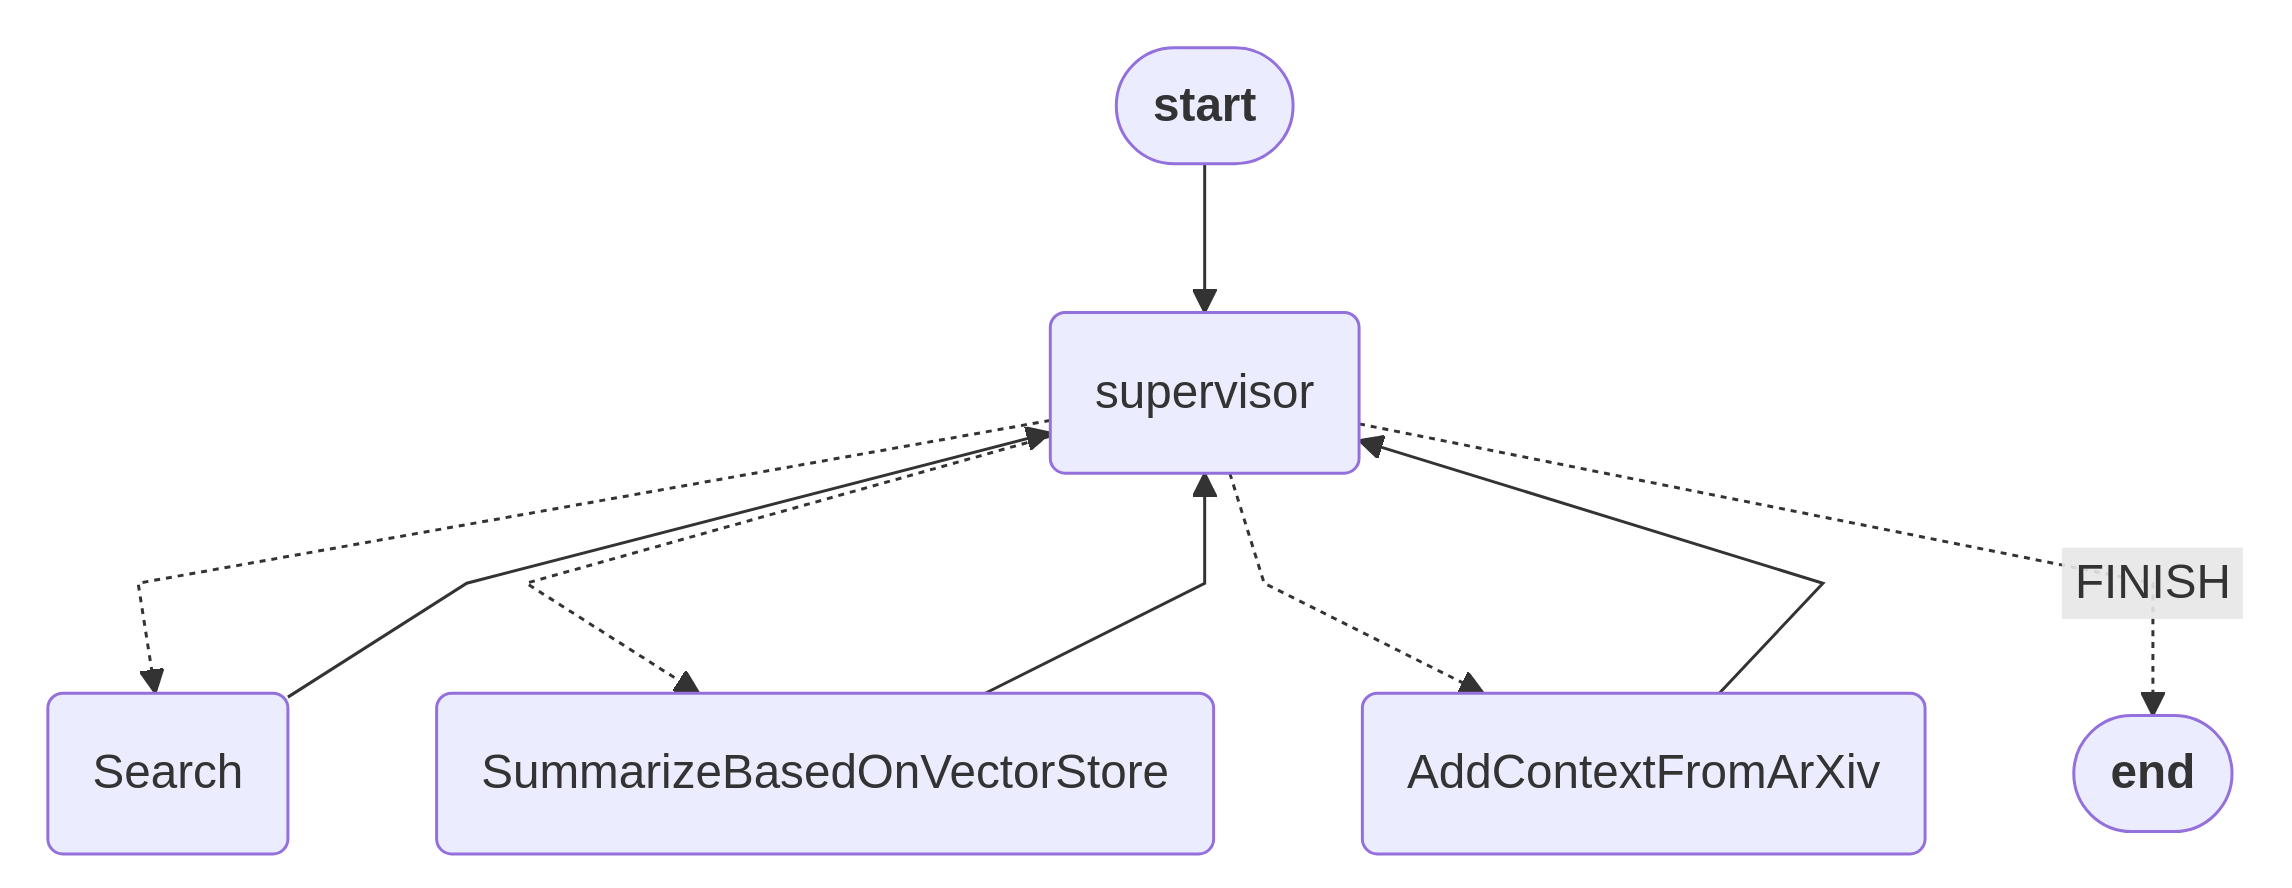

In [35]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        compiled_research_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

The next part is key - since we need to "wrap" our LangGraph in order for it to be compatible in the following steps - let's create an LCEL chain out of it!

This allows us to "broadcast" messages down to our Research Team LangGraph!

In [36]:
def enter_chain(message: str):
    results = {
        "messages": [HumanMessage(content=message)],
    }
    return results

research_chain = enter_chain | compiled_research_graph

Now, finally, we can take it for a spin!

In [37]:
def demo_research_chain(query:str):
    
    for s in research_chain.stream(
        query, 
        {"recursion_limit": 100}
    ):
        if "__end__" not in s:
            if 'supervisor' not in s.keys():
                for response in s.values():
                    for msg in response['messages']:
                        msg.pretty_print()
            else:
                print(s)
            print("---")
            


#### Demo: Scientific topic

OK, let's try a scientific topic! This should hit mostly ArXiv.

In [38]:
demo_research_chain("What can you tell me about 'lagrangian coherent structures'?")

{'supervisor': {'next': 'AddContextFromArXiv'}}
---


Bozo feed; consider handling: document declared as utf-8, but parsed as windows-1252


================================ Human Message =================================
Name: AddContextFromArXiv

I have retrieved the following papers related to "Lagrangian coherent structures" and added them to the RAG vector store:

1. **Three-Dimensional Lagrangian Coherent Structures in Patients with Aortic Regurgitation**
2. **Dissipative Inertial Transport Patterns near Coherent Lagrangian Eddies in the Ocean**

You can refer to these papers for more detailed information on the topic.
---
{'supervisor': {'next': 'SummarizeBasedOnVectorStore'}}
---
================================ Human Message =================================
Name: SummarizeVectorstoreData

Lagrangian coherent structures (LCS) are key concepts in dynamical systems theory, particularly relevant in fluid dynamics. They represent material surfaces or curves that effectively organize the flow of particles within a fluid, serving as barriers to transport and influencing particle motion over time. Recent research highligh

#### Demo: Non-scientific topic

This is about a kids show from Croatia. I'd be very surprised if there
is an arXiv paper on this.

In [39]:
demo_research_chain("What can you tell me about 'smogovci'?")

{'supervisor': {'next': 'AddContextFromArXiv'}}
---
================================ Human Message =================================
Name: AddContextFromArXiv

I found some papers related to the query 'smogovci' and added them to the RAG vector store. However, there were no specific titles or context provided. If you need more detailed information, please let me know!
---
{'supervisor': {'next': 'SummarizeBasedOnVectorStore'}}
---
================================ Human Message =================================
Name: SummarizeVectorstoreData

I was unable to find any specific information on "smogovci" from both the RAG vector store and ArXiv. If you have any other queries or need assistance with a different topic, feel free to ask!
---
{'supervisor': {'next': 'Search'}}
---
================================ Human Message =================================
Name: Search

"Smogovci" is a popular Croatian TV series that follows the adventures of the Vragec brothers, who live in a fictional su

#### 🏗️ Activity #2:

Using whatever drawing application you wish - please label the flow above on a diagram of your graph.

##### 🏗️ Activity #2 Response:

> I tried asking a question that would force exercising both agents.

>In my case the flow is:
> `start -> supervisor -> RAG -> supervisor -> search -> supervisor -> END`

![](graph-flow.png)

#### ❓ Question #2:

How could you make sure your Agent uses specific tools that you wish it to use? Are there any ways to concretely set a flow through tools?

##### ❗ Answer #2:

> I would first start with prompt engineering - asking the agent to 
> start by using tool "x" and then continue with "y".

> Alternatively, if we want to absolutely enforce the flow, perhaps 
> a reasoning agent is not the right tool to use (if it doesn't have autonomy, 
> what is there to reason). In that case we may want to enforce the flow
> by setting up a different topology in LangGraph.

> Related to this is an explicit set of options we may give the supervisor.
> In the current application, the "options" in `create_team_supervisor` contain
> all the tools. We could also give it only a partial list (including generating
> that list based on some more explicit logic in the routing function),

# 🤝 BREAKOUT ROOM #2

## Task 4: Document Writing Team - A LangGraph for Writing, Editing, and Planning a LinkedIn post.

Let's run it all back, this time specifically creating tools, agent nodes, and a graph for planning, writing, and editing a LinkedIn post!

### Tool Creation

Let's create some tools that will help us understand, open, work with, and edit documents to our liking!

In [40]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from typing_extensions import TypedDict
import uuid
import os

os.makedirs('./content/data', exist_ok=True)

def create_random_subdirectory():
    random_id = str(uuid.uuid4())[:8]  # Use first 8 characters of a UUID
    subdirectory_path = os.path.join('./content/data', random_id)
    os.makedirs(subdirectory_path, exist_ok=True)
    return subdirectory_path

WORKING_DIRECTORY = Path(create_random_subdirectory())

@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to save the document."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is not None:
        start = 0
    return "\n".join(lines[start:end])


@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document. Always use '.md' as the file extension.."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ] = {},
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"

##### 🏗️ Activity #3:

Describe, briefly, what each of these tools is doing in your own words.

##### 🏗️ Activity #3 response:

- `create_outline` - takes in a list of titles (strings) and writes an ordered list with those titles into a file
- `read_document` - reads the whole document and returns the segment between line numbers passed as parameters
- `write_document` - writes a string to a file with a given path, overwriting if needed.
- `edit_document`- inserts text at specified line numbers. (Note, since insertion grows the text, the line numbers after the first insertion won't correspond to insertion order. Perhaps a descending list was intended to preserve the order.)

### Document Writing State

Just like with our Research Team state - we want to keep track of a few things, however this time - we also want to keep track of which files we've created - so let's add that here!

In [41]:
import operator
from pathlib import Path

class DocWritingState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    team_members: str
    next: str
    current_files: str

### Document Writing Prelude Function

Since we have a working directory - we want to be clear about what our current working directory looks like - this helper function will allow us to do that cleanly!

In [42]:
def prelude(state):
    written_files = []
    if not WORKING_DIRECTORY.exists():
        WORKING_DIRECTORY.mkdir()
    try:
        written_files = [
            f.relative_to(WORKING_DIRECTORY) for f in WORKING_DIRECTORY.rglob("*")
        ]
    except:
        pass
    if not written_files:
        return {**state, "current_files": "No files written."}
    return {
        **state,
        "current_files": "\nBelow are files your team has written to the directory:\n"
        + "\n".join([f" - {f}" for f in written_files]),
    }

### Document Writing Node Creation



In [55]:
doc_writer_agent = create_agent(
    llm,
    [write_document, edit_document, read_document],
    """You are an expert writing technical LinkedIn posts.
Given an outline with notes, you follow it closely and make it more accessible
and engaging, but still technical.
You generate a draft of the document.
I am going to tip you $1000 if you attend to every section of the outline.
If links or references are provided, always include them in your document.
Below are files currently in your directory:
{current_files}""",
)
context_aware_doc_writer_agent = prelude | doc_writer_agent
doc_writing_node = functools.partial(
    agent_node, agent=context_aware_doc_writer_agent, name="DocDrafter"
)

note_taking_agent = create_agent(
    llm,
    [create_outline, read_document],
    """You are an expert senior researcher tasked with writing a LinkedIn post.
     You take in technical information, create an outline for it, and 
     add notes relevant to each section.
     If links or references are provided, always include them in your document.
     Below are files currently in your directory:
    {current_files}""",
)
context_aware_note_taking_agent = prelude | note_taking_agent
note_taking_node = functools.partial(
    agent_node, agent=context_aware_note_taking_agent, name="DocOutliner"
)

copy_editor_agent = create_agent(
    llm,
    [write_document, edit_document, read_document],
    ("You are an expert copy editor who focuses on fixing grammar, spelling, and tone issues\n"
     "If there is only an outline, report back 'I need a draft document!'"
     "If links or references are provided, always preserve them verbatim."
    "Below are files currently in your directory:\n{current_files}"),
)
context_aware_copy_editor_agent = prelude | copy_editor_agent
copy_editing_node = functools.partial(
    agent_node, agent=context_aware_copy_editor_agent, name="CopyEditor"
)

dopeness_editor_agent = create_agent(
    llm,
    [write_document, edit_document, read_document],
    """You are an expert in dopeness, litness, coolness, etc - you edit the 
    document to make sure it's dope.
    If there is only an outline or no document, report back "I need a draft document!"
    Make sure to use a number of emojis.
    EXUDE EXCESSIVE AMOUNTS OF ENTHUSIASM
    If links or references are provided, always preserve them verbatim.
    I am going to tip you if you make references to or quote from
    the popular 90s TV show "Fresh Prince of Bel-Air" in a way 
    that is funny and relevant to the content.
    Below are files currently in your directory:
    {current_files}"""
)
context_aware_dopeness_editor_agent = prelude | dopeness_editor_agent
dopeness_node = functools.partial(
    agent_node, agent=context_aware_dopeness_editor_agent, name="DopenessEditor"
)

doc_writing_supervisor = create_team_supervisor(
    llm,
    """You are a supervisor tasked with managing a conversation between the
    following workers: {team_members}. 
    Documents are first outlined, then drafted, then edited.
    You should always verify the technical
    contents after any edits are made. 
    Given the following user request,
    respond with the worker to act next. Each worker will perform a
    task and respond with their results and status. When each team is finished,
    you must respond with FINISH.""",
    ["DocDrafter", "DocOutliner", "DopenessEditor", "CopyEditor"],
)

### Document Writing Team LangGraph Construction

This part is almost exactly the same (with a few extra nodes) as our Research Team LangGraph construction - so we'll leave it as one block!

In [56]:
authoring_graph = StateGraph(DocWritingState)
authoring_graph.add_node("DocDrafter", doc_writing_node)
authoring_graph.add_node("DocOutliner", note_taking_node)
authoring_graph.add_node("CopyEditor", copy_editing_node)
authoring_graph.add_node("DopenessEditor", dopeness_node)
authoring_graph.add_node("supervisor", doc_writing_supervisor)

authoring_graph.add_edge("DocDrafter", "supervisor")
authoring_graph.add_edge("DocOutliner", "supervisor")
authoring_graph.add_edge("CopyEditor", "supervisor")
authoring_graph.add_edge("DopenessEditor", "supervisor")

authoring_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {
        "DocDrafter": "DocDrafter",
        "DocOutliner": "DocOutliner",
        "CopyEditor" : "CopyEditor",
        "DopenessEditor" : "DopenessEditor",
        "FINISH": END,
    },
)

authoring_graph.set_entry_point("supervisor")
compiled_authoring_graph = authoring_graph.compile()

#### Display Graph

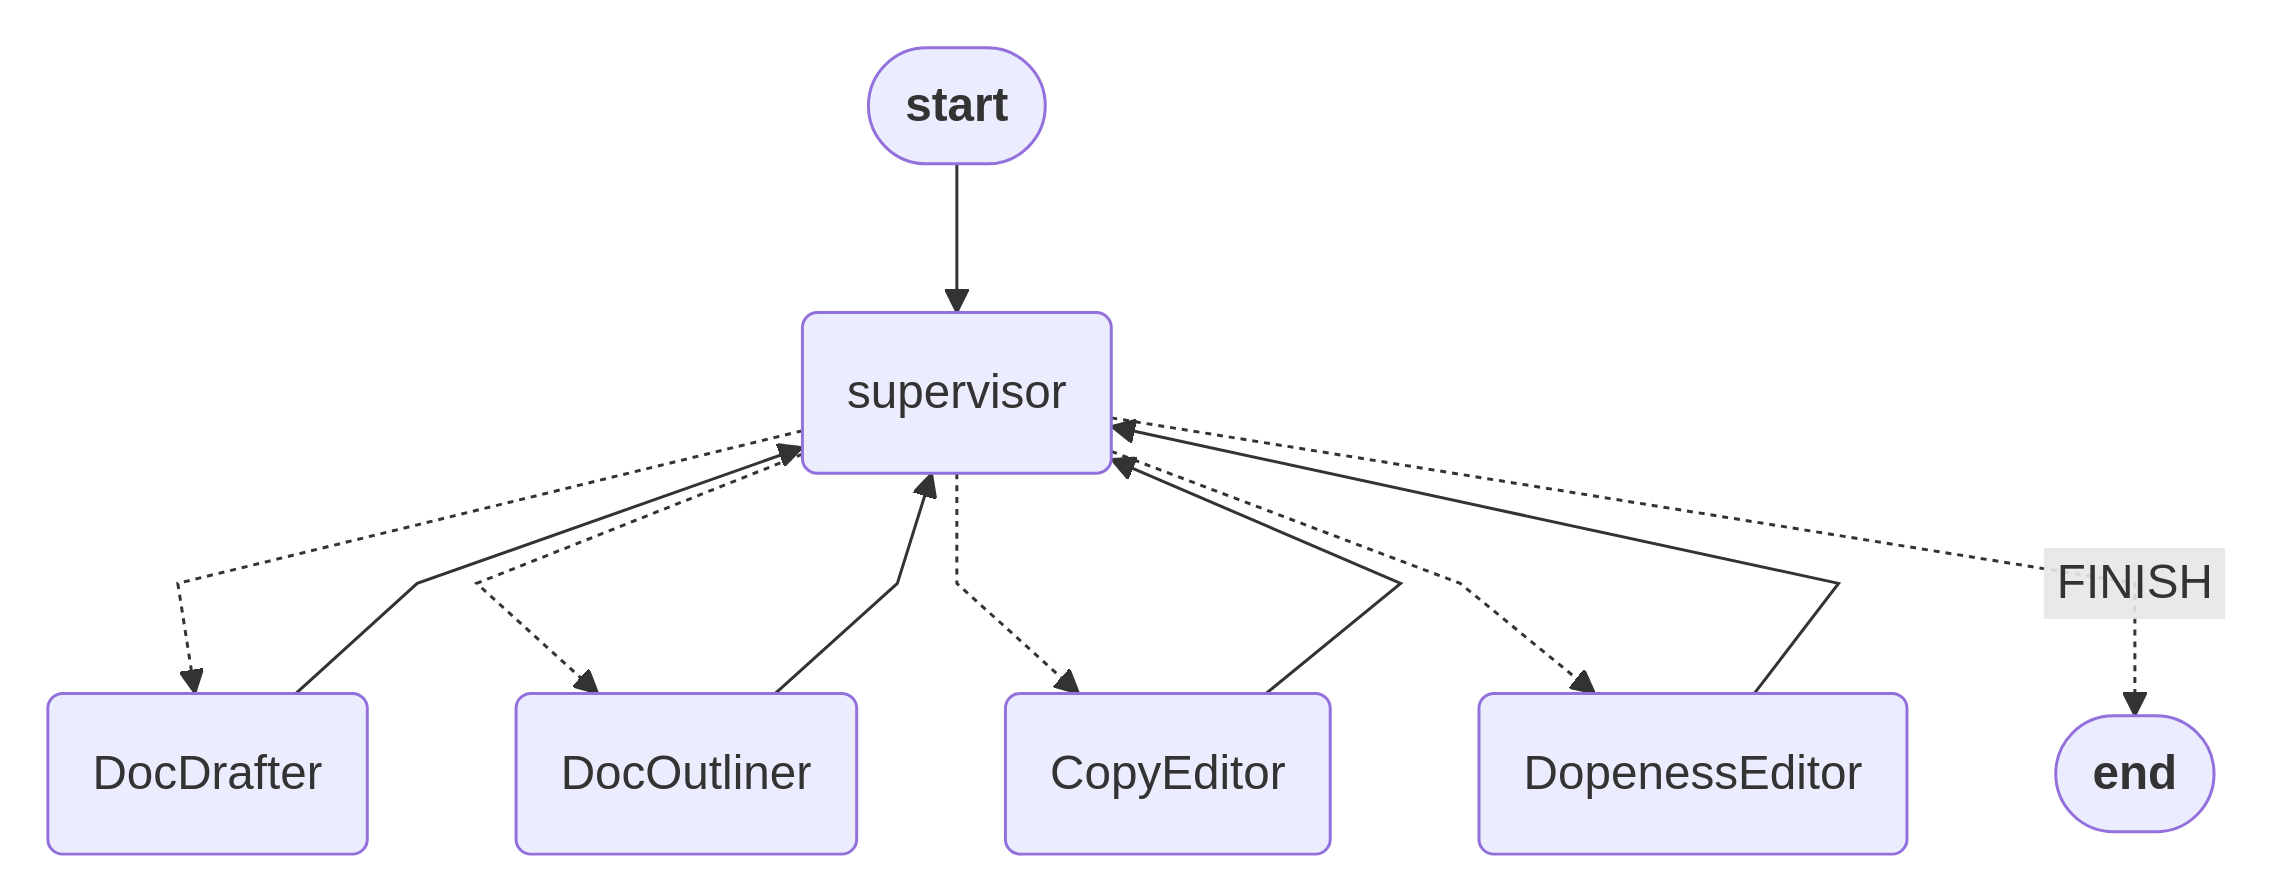

In [57]:
from IPython.display import Image, display

display(
    Image(
        compiled_authoring_graph.get_graph().draw_mermaid_png(
            curve_style=CurveStyle.LINEAR,
            node_colors=NodeStyles(first="#ffdfba", last="#baffc9", default="#fad7de"),
            wrap_label_n_words=9,
            output_file_path=None,
            draw_method=MermaidDrawMethod.PYPPETEER,
            background_color="white",
            padding=10,
        )
    )
)

Just as before - we'll need to create an "interface" between the level above, and our graph.

In [58]:
def enter_chain(message: str, members: List[str]):
    results = {
        "messages": [HumanMessage(content=message)],
        "team_members": ", ".join(members),
    }
    return results

authoring_chain = (
    functools.partial(enter_chain, members=authoring_graph.nodes)
    | authoring_graph.compile()
)

Now we can test this out!

> NOTE: It is possible you may see an error here - rerun the cell to clear.

In [59]:
for s in authoring_chain.stream(
    "Write an outline for for a short LinkedIn post on Linear Regression and write it to disk.",
    {"recursion_limit": 100},
):
        if 'supervisor' not in s.keys():
            for response in s.values():
                for msg in response['messages']:
                    msg.pretty_print()
        else:
            print(s)
        print("---")

{'supervisor': {'next': 'DocOutliner'}}
---
================================ Human Message =================================
Name: DocOutliner

I have created and saved an outline for a short LinkedIn post on Linear Regression. The outline includes the following sections:

1. **Introduction to Linear Regression**
2. **Key Concepts**
3. **Applications of Linear Regression**
4. **Conclusion**

If you need further details or content for any of these sections, feel free to ask!
---
{'supervisor': {'next': 'DocDrafter'}}
---
================================ Human Message =================================
Name: DocDrafter

I have created and saved the outline for a short LinkedIn post on Linear Regression. You can find it in the file named `linear_regression_outline.md`. If you need any further assistance or content for any of the sections, feel free to ask!
---
{'supervisor': {'next': 'CopyEditor'}}
---
================================ Human Message =================================
Name: C

## Task 5: Meta-Supervisor and Full Graph

Finally, now that we have our two LangGraph agents (some of which are already multi-agent), we can build a supervisor that sits above all of them!

The final process, surprisingly, is quite straight forward!

Let's jump in!

First off - we'll need to create our supervisor agent node.

In [60]:
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai.chat_models import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

supervisor_node = create_team_supervisor(
    llm,
    """You are a supervisor tasked with coordinating the following teams: {team_members}
    to write a well-researched and engaging LinkedIn post.
    Get the technical information from the research team and then pass it to the LinkedIn team to craft 
    a well-written LinkedIn post.
    Make sure to involve all team members at least once, but not more than 2 times each.
    Given the following user request, respond with the worker to act next. Each worker will perform a
 task and respond with their results and status. When all workers are finished,
 you must respond with FINISH.""",
    ["Research team", "LinkedIn team"],
)

We'll also create our new state - as well as some methods to help us navigate the new state and the subgraphs.

> NOTE: We only pass the most recent message from the parent graph to the subgraph, and we only extract the most recent message from the subgraph to include in the state of the parent graph.

In [61]:
class State(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]
    next: str

def get_last_message(state: State) -> str:
    return state["messages"][-1].content

def join_graph(response: dict):
    return {"messages": [response["messages"][-1]]}

Next, we'll create our base graph.

Notice how each node we're adding is *AN ENTIRE LANGGRAPH AGENT* (wrapped into an LCEL chain with our helper functions above).

In [62]:
super_graph = StateGraph(State)

super_graph.add_node("Research team", get_last_message | research_chain | join_graph)
super_graph.add_node(
    "LinkedIn team", get_last_message | authoring_chain | join_graph
)
super_graph.add_node("supervisor", supervisor_node)

Next, we'll create our edges!

This process is completely idenctical to what we've seen before - just addressing the LangGraph subgraph nodes instead of individual nodes.

In [63]:
super_graph.add_edge("Research team", "supervisor")
super_graph.add_edge("LinkedIn team", "supervisor")
super_graph.add_conditional_edges(
    "supervisor",
    lambda x: x["next"],
    {
        "LinkedIn team": "LinkedIn team",
        "Research team": "Research team",
        "FINISH": END,
    },
)
super_graph.set_entry_point("supervisor")
compiled_super_graph = super_graph.compile()

That's it!

Now we can finally use our full agent!

In [64]:
def write_linkedin_post_about_a_topic(topic: str):
    global WORKING_DIRECTORY
    WORKING_DIRECTORY = Path(create_random_subdirectory())
    print(WORKING_DIRECTORY)
    outputs = []
    for s in compiled_super_graph.stream(
        {
            "messages": [
                HumanMessage(
                    content=f"'{topic}'"
                )
            ],
        },
        {"recursion_limit": 10},
    ):
        if 'supervisor' not in s.keys():
            for response in s.values():
                for msg in response['messages']:
                    msg.pretty_print()
        else:
            print(s)
        print("---")
        outputs.append(s)
    
    print(WORKING_DIRECTORY)
    return outputs


## SAMPLE POST!

In [65]:
tda_output = write_linkedin_post_about_a_topic('Topological Data Analysis')


content/data/4ea71ab3


{'supervisor': {'next': 'Research team'}}
---
================================ Human Message =================================
Name: SummarizeVectorstoreData

Topological Data Analysis (TDA) is an innovative field within data science that utilizes topological methods to analyze complex, high-dimensional, and often noisy datasets. It has become popular due to its capability to reveal insights about the shape and structure of data, which is essential for various applications, including genetic data analysis, fraud detection, and biological studies.

Key tools in TDA include:

1. **Persistent Homology**: This concept focuses on the study of topological features of data across multiple scales, using persistence modules to track the birth and death of features as a parameter varies. This approach is closely related to algebraic geometry, particularly in extending persistent homology to multiple parameters through techniques from commutative algebra and algebraic combinatorics.

2. **Mapper 

GraphRecursionError: Recursion limit of 10 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.

🌟 **Topological Data Analysis (TDA): Unleashing Dope Insights from Complex Data!** 🌟  

Topological Data Analysis (TDA) is revolutionizing the way we interpret complex, high-dimensional datasets! 🚀 By leveraging topological methods, TDA reveals the underlying shape and structure of data, making it an essential tool for various applications, from genetic data analysis to fraud detection and biological studies! 🔍  

### Key Tools in TDA  

1. **Persistent Homology**:  
   - This method studies topological features across multiple scales, using persistence modules to track the birth and death of features as parameters change! 🎉 It’s closely related to algebraic geometry, with ongoing research extending persistent homology to multiple parameters through innovative techniques from commutative algebra and algebraic combinatorics!  
   - 📖 *Reference: Breiding, P. (2020). [An algebraic geometry perspective on topological data analysis](https://arxiv.org/abs/2001.02098).*  

2. **Mapper Algorithm**:  
   - A foundational tool in TDA, the Mapper algorithm constructs a simplicial complex that captures the topological structure of the data through clustering and graph representation! 🗺️ Recent advancements, like the Ball mapper algorithm, enhance exploratory data analysis, providing deeper insights into data shapes!  
   - 📖 *Reference: Dłotko, P. (2019). [Ball mapper: a shape summary for topological data analysis](https://arxiv.org/abs/1901.07410).*  

### Conclusion and Future Directions  

TDA stands at the crossroads of topology, algebra, and data science, offering powerful methodologies for extracting meaningful insights from complex datasets! 🌈 As research progresses, continuous advancements in techniques and shape descriptors promise to expand TDA’s capabilities across various scientific and practical domains!  

🎉 Let's embrace the potential of TDA in our data-driven world!  

#DataScience #TopologicalDataAnalysis #PersistentHomology #MapperAlgorithm #DataInsights #Research #Innovation  

---  

“Now this is a story all about how, TDA flipped the script and turned data around!” 😄✌️  
